<a href="https://colab.research.google.com/github/romiaprilian7406/ml-gdgoc-unsri/blob/main/LeNet_MNIST_Workshop_learning_session_9_Romi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop CNN: Klasifikasi Digit MNIST menggunakan LeNet-5

Selamat datang di workshop CNN! Pada sesi praktik ini, kita akan membangun model Convolutional Neural Network (CNN) menggunakan arsitektur klasik **LeNet-5** untuk mengenali angka tulisan tangan dari dataset **MNIST**.

## 1. Import Library
Pertama, mari kita import library yang dibutuhkan. Kita akan menggunakan TensorFlow dan Keras.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


## 2. Persiapan Data (MNIST)
Dataset MNIST terdiri dari 60.000 gambar training dan 10.000 gambar testing. Setiap gambar berukuran 28x28 pixel dalam format grayscale (hitam putih).

**Pre-processing:**
- **Normalisasi (/ 255.0)**: Nilai piksel asli adalah 0-255. Kita membaginya dengan 255 agar nilainya menjadi rentang 0-1. Model Deep Learning bekerja lebih cepat, stabil, dan optimal pada angka berskala kecil.
- **Dimensi Channel**: CNN pada Keras membutuhkan input berformat (Tinggi, Lebar, Channel). Untuk gambar berwarna (RGB) channel-nya 3, sedangkan *grayscale* (hitam-putih) channel-nya 1.

In [2]:
# Load dataset MNIST
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalisasi nilai pixel menjadi antara 0 dan 1
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# CNN membutuhkan dimensi channel. Kita tambahkan dimensi channel (1 untuk grayscale)
# Bentuk awal: (60000, 28, 28) menjadi (60000, 28, 28, 1)
train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

print("Shape Data Training:", train_images.shape)
print("Shape Data Testing:", test_images.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape Data Training: (60000, 28, 28, 1)
Shape Data Testing: (10000, 28, 28, 1)


### Visualisasi Data
Mari kita lihat beberapa contoh gambar dari dataset MNIST.

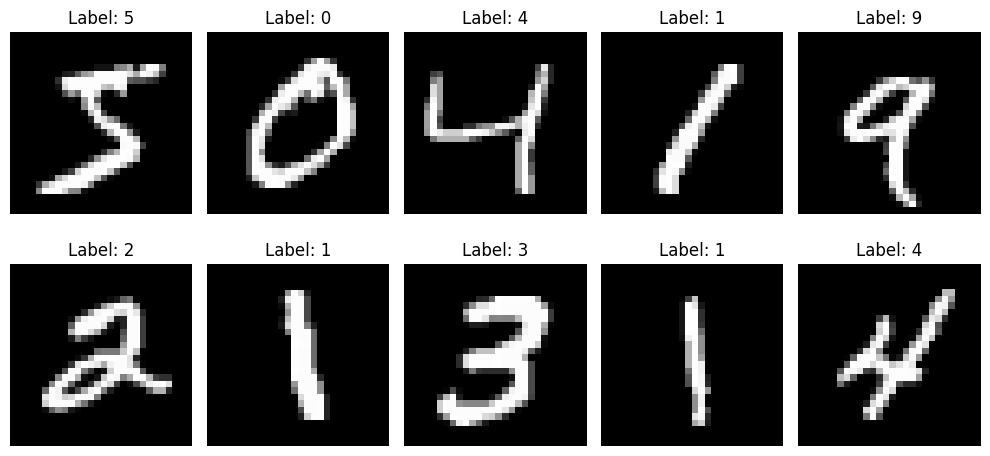

In [3]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(train_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Membangun Arsitektur LeNet-5
LeNet-5 adalah salah satu arsitektur CNN paling awal yang diciptakan oleh Yann LeCun (1998). Awalnya digunakan untuk mengenali cek dan kode pos.

**Komponen Utama CNN pada LeNet-5:**
1. **Conv2D (Convolutional Layer)**: Bertugas mengekstraksi fitur (seperti garis melengkung, tepi, dan sudut) dari gambar menggunakan filter/kernel (misal 5x5). Lapisan ini menscan gambar bagian demi bagian.
2. **AveragePooling2D**: Melakukan *downsampling* atau memperkecil ukuran dimensi gambar (misal dari 28x28 menjadi 14x14). Tujuannya untuk menghemat komputasi dan membantu model agar tidak menghafal data (*mencegah overfitting*).
3. **Flatten**: Meratakan matriks 2D menjadi vektor 1D. Ini merupakan jembatan penghubung karena lapisan *Dense* (Fully Connected) hanya bisa menerima input 1 dimensi.
4. **Dense (Fully Connected Layer)**: Lapisan jaringan saraf tiruan tradisional di mana semua neuron saling terhubung. Berfungsi menyatukan semua fitur yang telah diekstrak untuk membuat keputusan klasifikasi akhir.

In [4]:
model = models.Sequential([
    # Layer 1: Convolutional (6 filter, kernel 5x5)
    layers.Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)),

    # Layer 2: Average Pooling (pool size 2x2)
    layers.AveragePooling2D(pool_size=(2, 2)),

    # Layer 3: Convolutional (16 filter, kernel 5x5)
    layers.Conv2D(16, kernel_size=(5, 5), activation='relu'),

    # Layer 4: Average Pooling (pool size 2x2)
    layers.AveragePooling2D(pool_size=(2, 2)),

    # Flatten
    layers.Flatten(),

    # Layer 5: Fully Connected (120 neuron)
    layers.Dense(120, activation='relu'),

    # Layer 6: Fully Connected (84 neuron)
    layers.Dense(84, activation='relu'),

    # Layer 7: Output (10 neuron untuk 10 kelas digit)
    layers.Dense(10, activation='softmax')
])

# Tampilkan ringkasan model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compile Model
Sebelum dilatih, kita perlu mengatur proses pembelajaran (kompilasi) dengan tiga pengaturan penting:

- **Optimizer (adam)**: Algoritma yang bertugas memperbarui bobot (weights) model agar error-nya mengecil. Adam sangat populer karena ia secara otomatis menyesuaikan *learning rate* (langkah belajarnya).
- **Loss Function (sparse_categorical_crossentropy)**: Rumus pengukur kesalahan. Berfungsi menghitung *seberapa jauh* tebakan model dengan jawaban asli. Kita menggunakan awalan sparse karena label kelas kita berupa angka (0, 1, 2... 9), bukan array *one-hot encoding*.
- **Metrics (accuracy)**: Parameter yang ingin kita pantau selama training, yaitu persentase tebakan yang benar.

In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 5. Training Model
Tahap ini adalah proses di mana model benar-benar 'belajar' mengenali pola dari data gambar.

**Hyperparameter:**
- **Epochs (5)**: Berapa kali model akan belajar memproses *keseluruhan* data training. Jika epoch terlalu sedikit, model *underfitting* (belum paham). Jika terlalu banyak, model *overfitting* (terlalu hafal data latihan tapi gagal di data baru).
- **Batch Size (64)**: Model tidak memproses 60.000 gambar sekaligus (boros RAM) dan tidak satu per satu (terlalu lambat). Data dipecah menjadi kelompok-kelompok kecil berisi 64 gambar setiap kali bobot model diperbarui.
- **Validation Data**: Data testing yang digunakan pada setiap akhir epoch untuk menguji performa model pada data yang belum pernah dilihat sebelumnya.

In [6]:
history = model.fit(train_images, train_labels,
                    epochs=5,
                    batch_size=64,
                    validation_data=(test_images, test_labels))

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9161 - loss: 0.2857 - val_accuracy: 0.9733 - val_loss: 0.0852
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9741 - loss: 0.0849 - val_accuracy: 0.9802 - val_loss: 0.0637
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9808 - loss: 0.0610 - val_accuracy: 0.9878 - val_loss: 0.0420
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9847 - loss: 0.0477 - val_accuracy: 0.9876 - val_loss: 0.0395
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9879 - loss: 0.0389 - val_accuracy: 0.9898 - val_loss: 0.0302


## 6. Evaluasi Model
Kita evaluasi performa model pada data testing dan melihat grafik akurasi/loss.

In [7]:
# Evaluasi pada data testing
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nAkurasi Testing: {test_acc * 100:.2f}%")

313/313 - 1s - 4ms/step - accuracy: 0.9898 - loss: 0.0302

Akurasi Testing: 98.98%


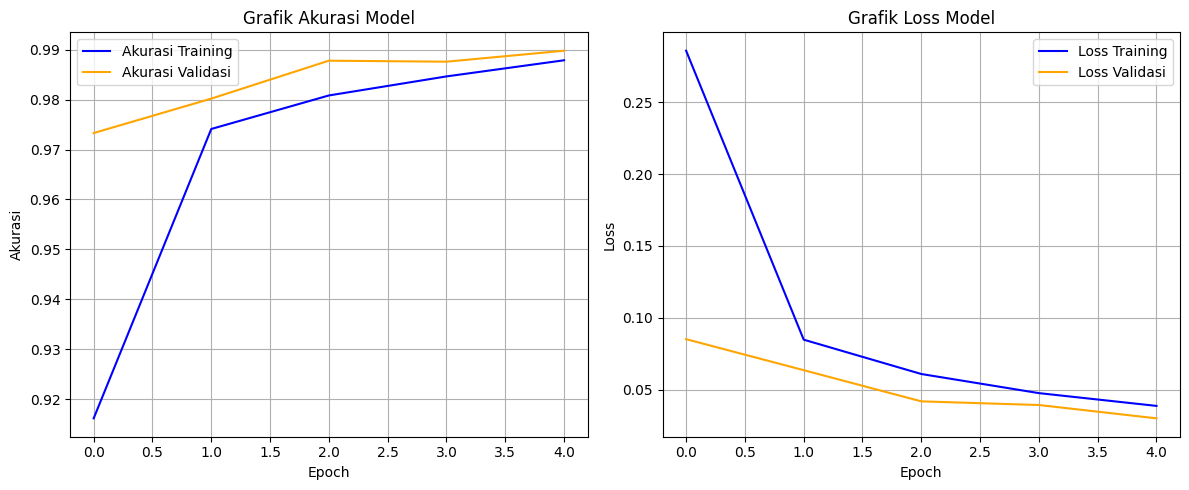

In [8]:
# Visualisasi Grafik Akurasi dan Loss
plt.figure(figsize=(12, 5))

# Subplot 1: Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Akurasi Training', color='blue')
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi', color='orange')
plt.title('Grafik Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Training', color='blue')
plt.plot(history.history['val_loss'], label='Loss Validasi', color='orange')
plt.title('Grafik Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Prediksi dengan Model yang Sudah Dilatih
Mari kita coba prediksi beberapa gambar dari data testing dan bandingkan dengan label aslinya.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


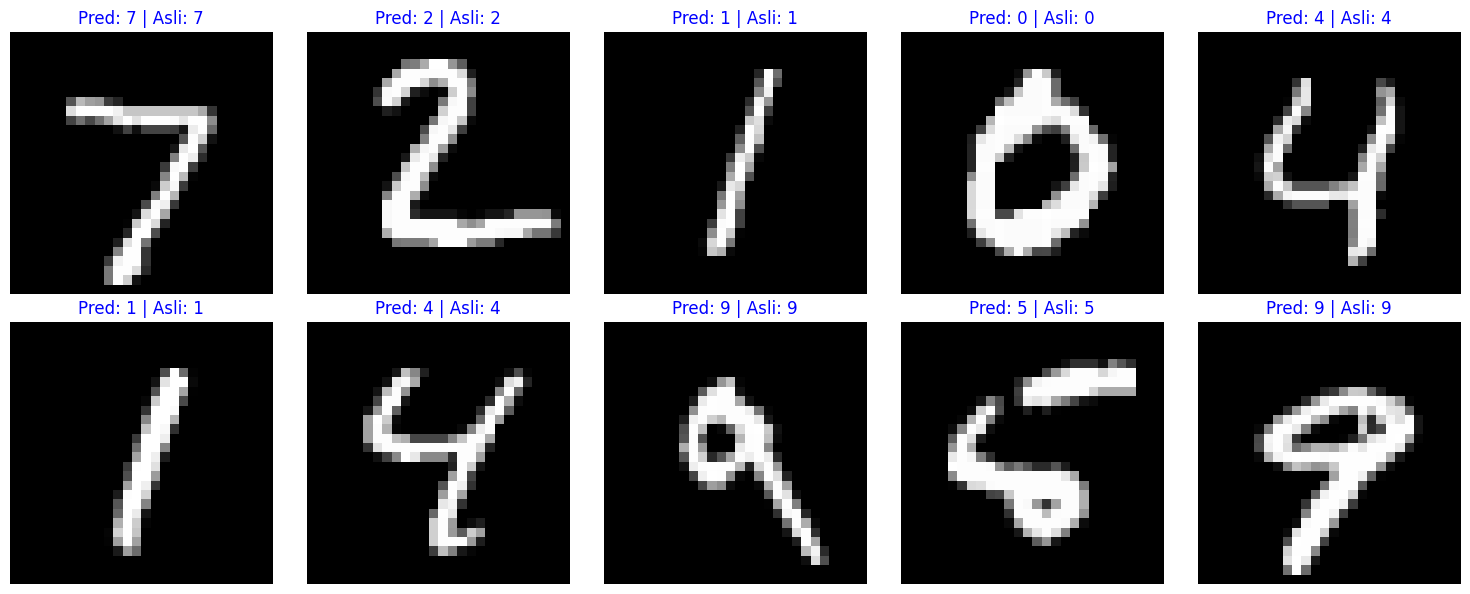

In [9]:
predictions = model.predict(test_images)

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray')

    pred_label = np.argmax(predictions[i])
    true_label = test_labels[i]

    color = 'blue' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label} | Asli: {true_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 8. Uji Coba dengan Gambar Sendiri (Lokal)
Anda dapat menguji model ini menggunakan gambar tulisan tangan Anda sendiri. Simpan gambar angka dengan nama digit_saya.png di folder yang sama dengan notebook ini.

**Catatan Penting (Pre-processing):**
Model dilatih dengan dataset MNIST di mana **background berwarna hitam (nilai pixel 0)** dan **tulisan berwarna putih (nilai pixel 255)**. Jika foto yang kalian upload memiliki *background* putih (misal kertas) dengan tulisan hitam (misal tinta pulpen), model bisa kebingungan.
Untuk mengatasinya, Anda wajib membalik warnanya (*invert*) dengan menghapus tanda pagar (#) pada baris kode img_array = 255.0 - img_array di bawah ini.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step


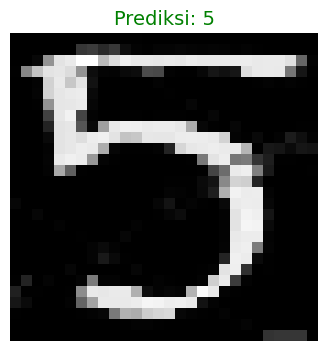

In [10]:
import os
from tensorflow.keras.preprocessing import image

image_path = '5_2.png'

if os.path.exists(image_path):
    # Load gambar, ubah ke grayscale dan resize ke 28x28
    img = tf.keras.utils.load_img(image_path, color_mode="grayscale", target_size=(28, 28))

    # Konversi ke array NumPy
    img_array = tf.keras.utils.img_to_array(img)

    # (Opsional) MNIST menggunakan background hitam (0) dan angka putih (255).
    # Jika gambar Kalian memiliki background putih dan angka hitam, uncomment baris ini:
    img_array = 255.0 - img_array

    # Normalisasi
    img_normalized = img_array.astype('float32') / 255.0

    # Tambahkan dimensi batch menjadi (1, 28, 28, 1)
    img_input = np.expand_dims(img_normalized, axis=0)

    # Prediksi
    prediction = model.predict(img_input)
    predicted_label = np.argmax(prediction)

    # Tampilkan
    plt.figure(figsize=(4, 4))
    plt.imshow(img_array[:, :, 0], cmap='gray')
    plt.title(f'Prediksi: {predicted_label}', color='green', fontsize=14)
    plt.axis('off')
    plt.show()
else:
    print(f'File {image_path} tidak ditemukan. Silakan tambahkan file gambar terlebih dahulu.')